In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.spatial.distance import cdist
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score

In [5]:
def full_cw_sil_score(X, labels):

    X = np.asarray(X)
    labels = np.asarray(labels)

    n = len(X)
    unique_labels = np.unique(labels)

    #pairwise distance matrix
    D = cdist(X, X)

    # computation of centroids
    centroids = {
        l: X[labels == l].mean(axis=0)
        for l in unique_labels
    }

    # distance to centroid
    dist_to_centroid = np.zeros(n)
    for i in range(n):
        d = np.linalg.norm(X[i] - centroids[labels[i]])
        dist_to_centroid[i] = d + 1e-8   # to avoid zero

    silhouette_scores = np.zeros(n)

    for i in range(n):

        # a(i) 
        same_cluster = (labels == labels[i])
        same_cluster[i] = False  # to exclude self

        if not np.any(same_cluster):
            silhouette_scores[i] = 0
            continue

        intra_dist = D[i, same_cluster]
        intra_weights = 1.0 / dist_to_centroid[same_cluster]

        a = np.sum(intra_dist * intra_weights) / np.sum(intra_weights)

        # b(i)
        b = np.inf

        for l in unique_labels:
            if l == labels[i]:
                continue

            mask = (labels == l)
            inter_dist = D[i, mask]
            inter_weights = 1.0 / dist_to_centroid[mask]

            b_l = np.sum(inter_dist * inter_weights) / np.sum(inter_weights)
            b = min(b, b_l)

        # silhouette score for i
        silhouette_scores[i] = (b - a) / max(a, b)

    return silhouette_scores.mean()

In [6]:
def cw_sil_score(X, labels):

    X = np.asarray(X)
    labels = np.asarray(labels)

    n = len(X)
    unique_labels = np.unique(labels)

    # pairwise distance matrix
    D = cdist(X, X)

    # centroids
    centroids = {
        l: X[labels == l].mean(axis=0)
        for l in unique_labels
    }

    # distance to centroid
    dist_to_centroid = np.zeros(n)
    for i in range(n):
        d = np.linalg.norm(X[i] - centroids[labels[i]])
        dist_to_centroid[i] = d + 1e-8   # avoid zero

    silhouette_scores = np.zeros(n)

    for i in range(n):

        # a(i) 
        same_cluster = (labels == labels[i])
        same_cluster[i] = False  # exclude self

        if not np.any(same_cluster):
            silhouette_scores[i] = 0
            continue

        intra_dist = D[i, same_cluster]
        intra_weights = 1.0 / dist_to_centroid[same_cluster]

        a = np.sum(intra_dist * intra_weights) / np.sum(intra_weights)

        # b(i)
        b = np.inf

        for l in unique_labels:
            if l == labels[i]:
                continue

            mask = (labels == l)
            inter_dist = D[i, mask]
            #inter_weights = 1.0 / dist_to_centroid[mask]

            b_l = np.sum(inter_dist) / len(inter_dist)
            b = min(b, b_l)

        # silhouette score for i
        silhouette_scores[i] = (b - a) / max(a, b)

    return silhouette_scores.mean()

# Silhouette Variants

In [7]:
rng = np.random.default_rng(51)

centroids = np.array([
    [5.0, 3.0],
    [7.0, 7.0],
    [3.0, 7.0]
])

n_samples_per_cluster = 67
std_values = [0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.5, 2.0]

runs = 10 

In [8]:
results = []

for std in std_values:
    for run in range(10):
        
        X = np.vstack([
            rng.normal(loc=center, scale=std,
                             size=(n_samples_per_cluster, 2))
            for center in centroids
        ])

        labels = np.repeat([0, 1, 2], n_samples_per_cluster)

        s_std = silhouette_score(X, labels)
        s_fullcw = full_cw_sil_score(X, labels)
        s_cw = cw_sil_score(X, labels)

        results.append([std, run, s_std, s_fullcw, s_cw])


In [9]:
df_results = pd.DataFrame(results, columns=["std", "run", "standard_silhouette", "full_cw_silhouette", "cw_silhouette"])   
df_results["diff_fullcw_minus_std"] = (df_results["full_cw_silhouette"] - df_results["standard_silhouette"])
df_results["diff_cw_minus_std"] = (df_results["cw_silhouette"] - df_results["standard_silhouette"])
display(df_results)

,std,run,standard_silhouette,full_cw_silhouette,cw_silhouette,diff_fullcw_minus_std,diff_cw_minus_std
0,0.2,0,0.909272,0.922849,0.922823,0.013576,0.013551
1,0.2,1,0.912503,0.925716,0.925783,0.013213,0.013280
2,0.2,2,0.915860,0.927456,0.927632,0.011597,0.011772
3,0.2,3,0.916480,0.929997,0.930175,0.013517,0.013694
4,0.2,4,0.911308,0.922689,0.922751,0.011381,0.011443
...,...,...,...,...,...,...,...
75,2.0,5,0.209656,0.255037,0.319305,0.045381,0.109649
76,2.0,6,0.218918,0.265382,0.316597,0.046464,0.097679
77,2.0,7,0.151987,0.192545,0.265388,0.040558,0.113401
78,2.0,8,0.178268,0.218551,0.285505,0.040283,0.107238


In [10]:
grouped = df_results.groupby("std")

grouped = grouped.agg(
    mean_std=("standard_silhouette", "mean"),
    se_std=("standard_silhouette", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
    
    mean_fullcw=("full_cw_silhouette", "mean"),
    se_fullcw=("full_cw_silhouette", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
    
    mean_cw=("cw_silhouette", "mean"),
    se_cw=("cw_silhouette", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
    
    mean_diff_fullcw=("diff_fullcw_minus_std", "mean"),
    se_diff_fullcw=("diff_fullcw_minus_std", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
    
    mean_diff_cw=("diff_cw_minus_std", "mean"),
    se_diff_cw=("diff_cw_minus_std", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
)

display(grouped)

,mean_std,se_std,mean_fullcw,se_fullcw,mean_cw,se_cw,mean_diff_fullcw,se_diff_fullcw,mean_diff_cw,se_diff_cw
std,,,,,,,,,,
0.2,0.914778,0.000975,0.926768,0.000777,0.926827,0.000787,0.011990,0.000471,0.012049,0.000475
0.4,0.826595,0.002537,0.850004,0.002380,0.850292,0.002333,0.023409,0.000730,0.023697,0.000687
0.6,0.727720,0.004038,0.762040,0.003528,0.763542,0.003441,0.034320,0.001010,0.035822,0.001143
0.8,0.639800,0.004149,0.682531,0.003643,0.686391,0.003485,0.042731,0.001649,0.046591,0.001730
1.0,0.547511,0.006941,0.597073,0.005366,0.605857,0.004939,0.049563,0.002143,0.058346,0.002489
1.2,0.461738,0.006970,0.517020,0.006488,0.532256,0.006068,0.055282,0.002289,0.070517,0.003098
1.5,0.342152,0.009821,0.397400,0.011330,0.427302,0.010435,0.055248,0.001995,0.085150,0.001955
2.0,0.191910,0.010731,0.234056,0.011614,0.295915,0.008788,0.042145,0.001377,0.104004,0.003369


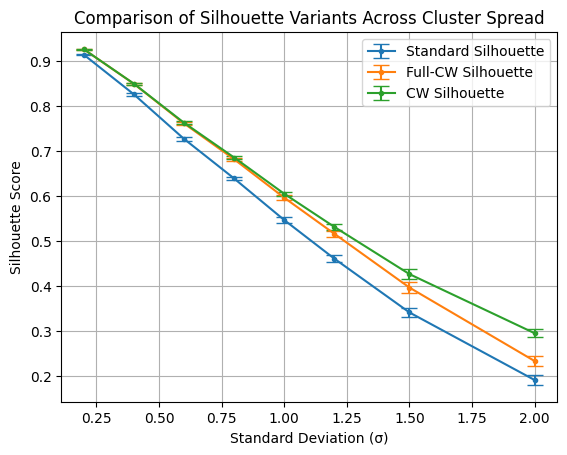

In [11]:
plt.errorbar(
    grouped.index,
    grouped["mean_std"],
    yerr=grouped["se_std"],
    label="Standard Silhouette",
    marker=".",
    capsize=6
)

plt.errorbar(
    grouped.index,
    grouped["mean_fullcw"],
    yerr=grouped["se_fullcw"],
    label="Full-CW Silhouette",
    marker=".",
    capsize=6
)

plt.errorbar(
    grouped.index,
    grouped["mean_cw"],
    yerr=grouped["se_cw"],
    label="CW Silhouette",
    marker=".",
    capsize=6
)

plt.xlabel("Standard Deviation (σ)")
plt.ylabel("Silhouette Score")
plt.title("Comparison of Silhouette Variants Across Cluster Spread")
plt.grid(True)
plt.legend()

plt.show()

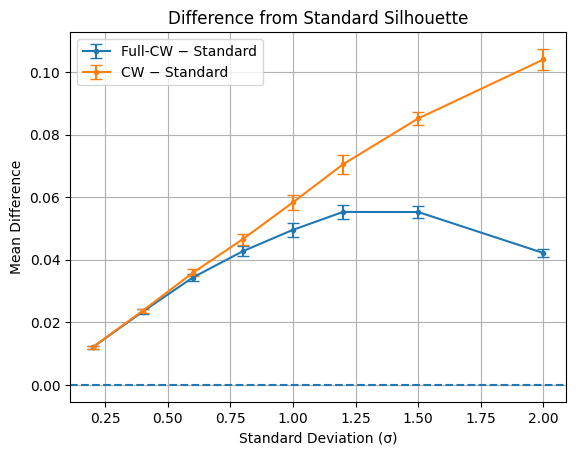

In [12]:
plt.errorbar(
    grouped.index,
    grouped["mean_diff_fullcw"],
    yerr=grouped["se_diff_fullcw"],
    marker=".",
    capsize=4,
    label="Full-CW − Standard"
)

plt.errorbar(
    grouped.index,
    grouped["mean_diff_cw"],
    yerr=grouped["se_diff_cw"],
    marker=".",
    capsize=4,
    label="CW − Standard"
)

plt.axhline(0, linestyle="--")
plt.xlabel("Standard Deviation (σ)")
plt.ylabel("Mean Difference")
plt.title("Difference from Standard Silhouette")
plt.legend()
plt.grid()

plt.show()

# Adding Noise

In [13]:
noise_percentages = range(1, 11)

In [14]:
results = []

for run in range(runs):

    # generating clean dataset 
    X_clean = np.vstack([   # 3 cluster dataset with approx 200 points
        np.random.normal(loc=center, scale=0.4,
                         size=(n_samples_per_cluster, 2))
        for center in centroids
    ])

    base_n = len(X_clean)

    # check for range for uniform noise
    xmin, ymin = X_clean.min(axis=0)
    xmax, ymax = X_clean.max(axis=0)

    for noise_pct in noise_percentages:

        # computing no. of noise points
        n_noise = int((noise_pct / 100) * base_n)

        #generation of uniform noise
        noise = np.random.uniform(
            low=[xmin, ymin],
            high=[xmax, ymax],
            size=(n_noise, 2)   
        )

        #combining clean and noisy points
        X_noisy = np.vstack([X_clean, noise])


        kmeans = KMeans(n_clusters=3, n_init=10, random_state=run)
        labels = kmeans.fit_predict(X_noisy)    
        s_std = silhouette_score(X_noisy, labels)
        s_full_cw = full_cw_sil_score(X_noisy, labels)
        s_cw = cw_sil_score(X_noisy, labels)

        results.append([noise_pct, run, s_std, s_full_cw, s_cw])

In [15]:
results = np.array(results)

mean_std = []
mean_fullcw = []
mean_cw = []

mean_diff_fullcw = []
mean_diff_cw = []

for noise_pct in noise_percentages:

    mask = results[:, 0] == noise_pct

    std_vals = results[mask][:, 2]
    fullcw_vals = results[mask][:, 3]
    cw_vals = results[mask][:, 4]

    mean_std.append(np.mean(std_vals))
    mean_fullcw.append(np.mean(fullcw_vals))
    mean_cw.append(np.mean(cw_vals))

    mean_diff_fullcw.append(np.mean(fullcw_vals - std_vals))
    mean_diff_cw.append(np.mean(cw_vals - std_vals))

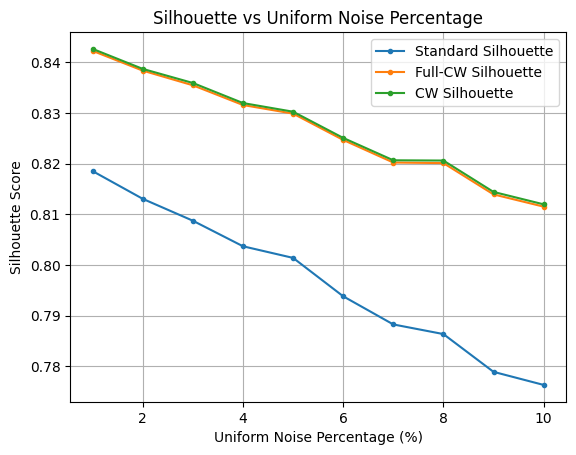

In [16]:
plt.figure()

plt.plot(noise_percentages, mean_std, marker=".", label="Standard Silhouette")
plt.plot(noise_percentages, mean_fullcw, marker=".", label="Full-CW Silhouette")
plt.plot(noise_percentages, mean_cw, marker=".", label="CW Silhouette")

plt.xlabel("Uniform Noise Percentage (%)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette vs Uniform Noise Percentage")

plt.legend()
plt.grid(True)

plt.show()

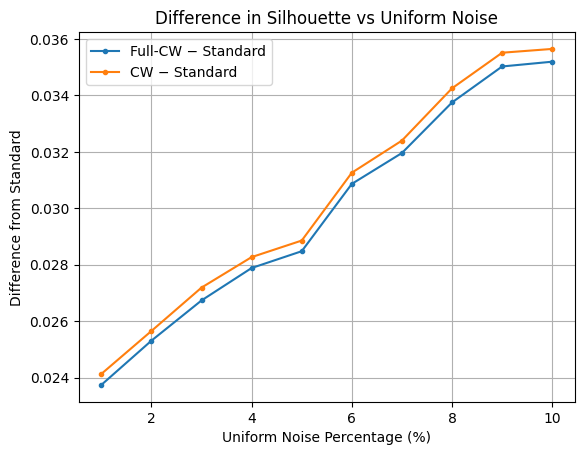

In [17]:
plt.figure()

plt.plot(noise_percentages, mean_diff_fullcw, marker=".", label="Full-CW − Standard")
plt.plot(noise_percentages, mean_diff_cw, marker=".", label="CW − Standard")

plt.xlabel("Uniform Noise Percentage (%)")
plt.ylabel("Difference from Standard")
plt.title("Difference in Silhouette vs Uniform Noise")

plt.legend()
plt.grid(True)

plt.show()